# Unpaired Image-to-Image Translation with CycleGAN
## PyTorch Implementation (Horse <-> Zebra)

### Project Overview & Objectives
This project implements a CycleGAN architecture for unpaired image-to-image translation between horses and zebras. 
Additionally, we evaluate the model's out-of-distribution generalization on unseen photographs of Iranian Turkoman horses.


Dataset Link: https://www.kaggle.com/datasets/balraj98/horse2zebra-dataset/data

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Dataset, DataLoader
import os # Imp

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
# import glob
from pathlib import Path
import pathlib

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [27]:
# Device configuration (only needs to be done once)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Using device:', device)
print()

# Additional CUDA information
if device.type == 'cuda':
    print(f"1. CUDA Device Name: {torch.cuda.get_device_name(0)}")
    print(f"2. CUDA Compute Capability: {torch.cuda.get_device_capability(0)}")
    print(f"3. CUDA Device Memory: {round(torch.cuda.get_device_properties(0).total_memory/1e9, 2)} GB")
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3, 1), 'GB')
    print('Reserved: ', round(torch.cuda.memory_reserved(0)/1024**3, 1), 'GB')  # Changed from "Cached"

Using device: cuda

1. CUDA Device Name: NVIDIA GeForce MX130
2. CUDA Compute Capability: (5, 0)
3. CUDA Device Memory: 2.15 GB
Memory Usage:
Allocated: 0.4 GB
Reserved:  0.6 GB


In [5]:
# Define hyperparameters and dataset paths
DATASET_ROOT = './src/data/horse2zebra/'
Dataset_Link = 'https://www.kaggle.com/datasets/balraj98/horse2zebra-dataset/data'
DATASET_ROOT = Path(DATASET_ROOT).resolve()

TRAIN_A_DIR = Path(DATASET_ROOT) / 'trainA' # Domain A: Horses (+ Iranian horses)
TRAIN_B_DIR = Path(DATASET_ROOT) / 'trainB' # Domain B: Zebras
TEST_A_DIR = Path(DATASET_ROOT) / 'testA'   # Test Domain A
TEST_B_DIR = Path(DATASET_ROOT) / 'testB'   # Test Domain B
MODEL_DIR = Path('./src/Model/')


IMG_SIZE = 256
IMG_CHANNELS = 3 # RGB
BATCH_SIZE = 1 # For CycleGAN, we use a batch size of 1 because the images are large and we want to avoid running out of memory.
NUM_WORKERS = 4 # Number of workers for data loading
LR = 2e-4 # Learning rate
EPOCHS = 200 # Number of epochs
LAMBDA_CYCLE = 10 # Cycle consistency loss weight |
LAMBDA_ID = 0.5 # Identity loss weight | 0.5 is a good starting point for the identity loss weight
LAMBDA_GAN = 1 # GAN loss weight | 1 is a good starting point for the GAN loss weight

In [6]:
# Transformations
# As per CycleGAN paper:
# 1. Resize to 286x286 with bicubic interpolation
# 2. Random crop to 256x256
# 3. Random horizontal flip
# 4. Normalize to [-1, 1] range

transform = transforms.Compose([
    transforms.Resize((286, 286), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomCrop((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)), # (image - 0.5) / 0.5)
])

# Custom dataset class for loading images
class ImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Initializes the dataset by loading image paths from the specified directory.
        Args:
            root_dir (str): Directory containing the images.
            transform (callable, optional): Optional transform to be applied on an image.
        """
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.image_paths = list(self.root_dir.glob('*.jpg')) + list(self.root_dir.glob('*.png'))

        if not self.image_paths:
            raise ValueError(f"No images found in directory: {self.root_dir}")

    def __len__(self):
        """
        Returns the total number of images in the dataset.
        Returns:
            int: Number of images in the dataset.
        """
        return len(self.image_paths)

    def __getitem__(self, idx):
        """
        Fetches the image at the specified index and applies transformations.
        Args: 
            idx (int): Index of the image to fetch.
        Returns:
            image (Tensor): Transformed image tensor.
        """
        try:
            img_path = self.image_paths[idx]
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image
        except Exception as e:
            print(f"Error loading image at index {idx}: {e}")
            return None

In [7]:
# Download and load the dataset
print(f"Checking dataset paths:\nDomain A (horses): {TRAIN_A_DIR}\nDomain B (zebras): {TRAIN_B_DIR}")

Checking dataset paths:
Domain A (horses): /mnt/e/University/Modares/Courses/DP MJ/HW/2/src/data/horse2zebra/trainA
Domain B (zebras): /mnt/e/University/Modares/Courses/DP MJ/HW/2/src/data/horse2zebra/trainB


In [10]:
# Check if directory existsy
if not TRAIN_A_DIR.exists() or not TRAIN_B_DIR.exists():
    print(f"Dataset directories do not exist. \nPlease download the dataset from {Dataset_Link} \nand extract it to {DATASET_ROOT}.")
else:
    print(f"Dataset directories exist. Proceeding to load the dataset.")
    # # Download the dataset
    # import kagglehub
    # # set kaggle API key using secure way
    # kaggle_api_key = kagglehub.get_kaggle_api_key()
    # kagglehub.set_kaggle_api_key(kaggle_api_key)
    # kagglehub.download_dataset(Dataset_Link, path=DATASET_ROOT)
    # print(f"Dataset downloaded to {DATASET_ROOT}.")

Dataset directories exist. Proceeding to load the dataset.


In [11]:
# Create Datasets
train_dataset_A = ImageDataset(root_dir=TRAIN_A_DIR, transform=transform)
train_dataset_B = ImageDataset(root_dir=TRAIN_B_DIR, transform=transform)
test_dataset_A = ImageDataset(root_dir=TEST_A_DIR, transform=transform)
test_dataset_B = ImageDataset(root_dir=TEST_B_DIR, transform=transform)


# Create DataLoaders
train_DataLoader_A = DataLoader(
    train_dataset_A,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True, # Drop the last incomplete batch
    pin_memory=True # Pin memory for faster data transfer to GPU
)
train_DataLoader_B = DataLoader(
    train_dataset_B,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True, # Drop the last incomplete batch
    pin_memory=True # Pin memory for faster data transfer to GPU
)
test_DataLoader_A = DataLoader(
    test_dataset_A,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    drop_last=False, # Keep the last incomplete batch
    pin_memory=True # Pin memory for faster data transfer to GPU
)
test_DataLoader_B = DataLoader(
    test_dataset_B,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    drop_last=False, # Keep the last incomplete batch
    pin_memory=True # Pin memory for faster data transfer to GPU
)

# Check if the datasets are loaded correctly
print(f"Number of training images in Domain A (Horse): {len(train_dataset_A)}")
print(f"Number of training images in Domain B (Zebra): {len(train_dataset_B)}")
print(f"Number of test images in Domain A: {len(test_dataset_A)}")
print(f"Number of test images in Domain B: {len(test_dataset_B)}")

Number of training images in Domain A (Horse): 1067
Number of training images in Domain B (Zebra): 1334
Number of test images in Domain A: 120
Number of test images in Domain B: 140


Visualizing Training Data:


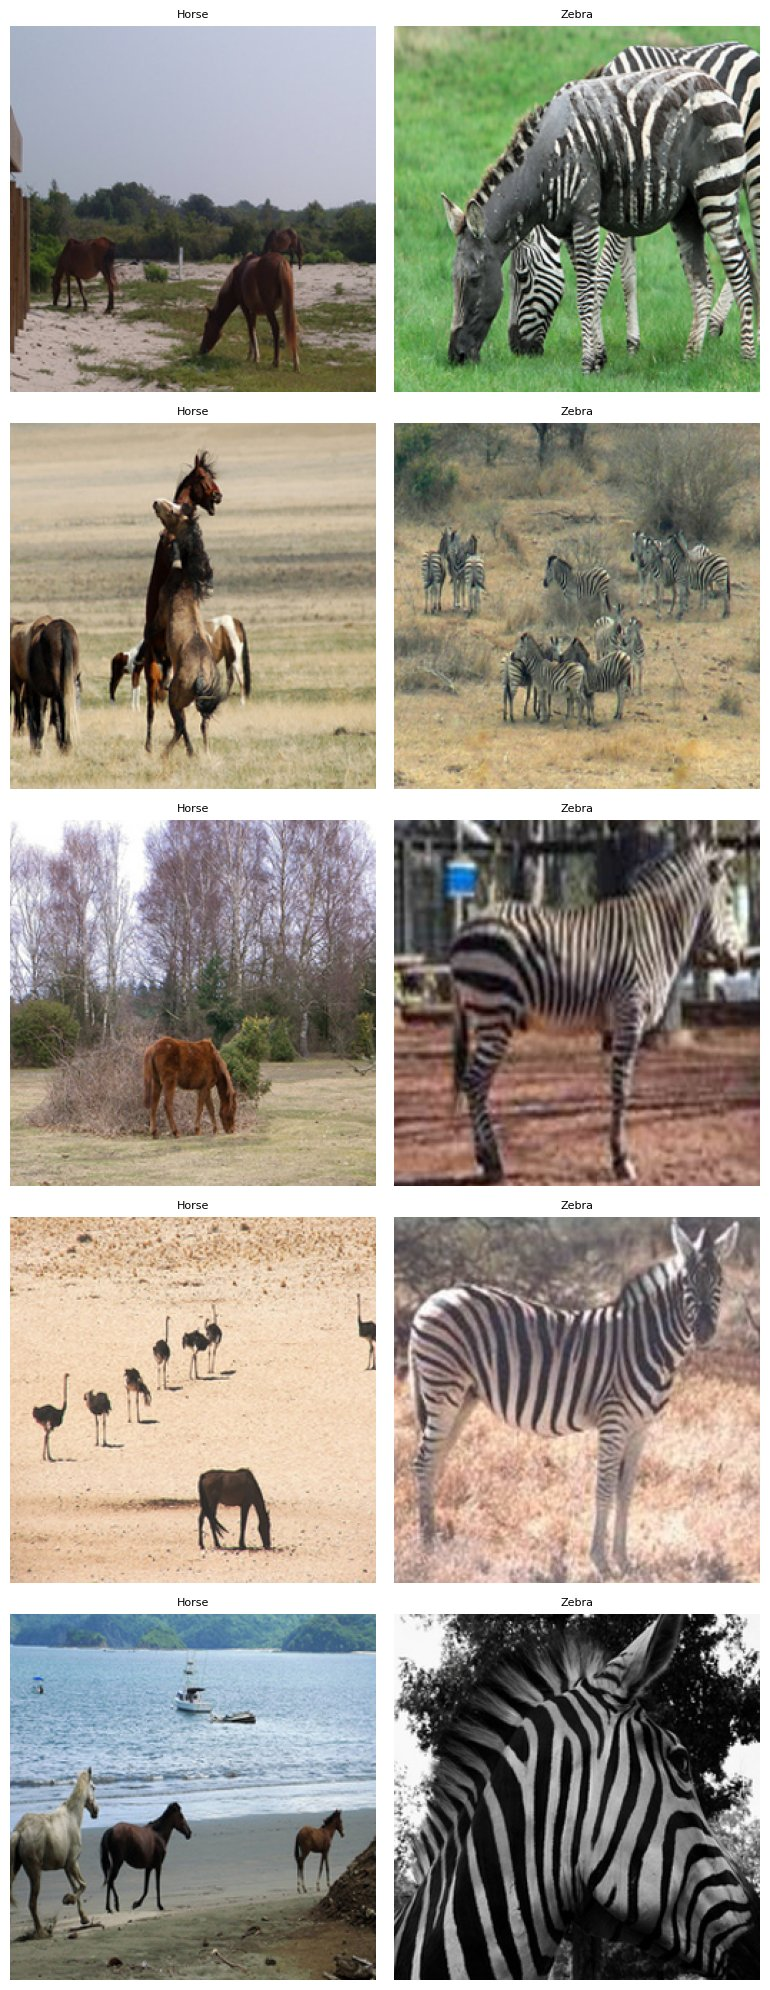

In [ ]:
# Utility functions for displaying images
def get_random_batch(dataloader):
    return next(iter(dataloader))

def show_images(images, titles="", ncols=5, figsize=(15, 3)):
    """
    Displays a grid of images with optional titles.
    Args:
        images (Tensor): Batch of images to display.
        titles (list, optional): List of titles for each image.
        ncols (int, optional): Number of columns in the grid.
        figsize (tuple, optional): Size of the figure.
    """
    plt.figure(figsize=figsize)

    # Convert tensor to numpy and denormalize
    images = images.cpu().detach()
    images = (images + 1) / 2  # Denormalize to [0, 1]
    images = images.clamp(0, 1) # To ensure valid pixel range
    images = images.permute(0, 2, 3, 1).numpy()  # Convert to (N, H, W, C)

    n_images = len(images)
    nrows = int(np.ceil(n_images / ncols))


    for idx in range(n_images):
      plt.subplot(nrows, ncols, idx+1)
      plt.imshow(images[idx])
      if titles and idx < len(titles):
          plt.title(titles[idx], fontsize=8)
      plt.axis('off')

    plt.tight_layout()
    plt.show()

def visualize_domains(loader_A, loader_B, n_samples=5):
    """
    Visualizes a n number of samples from each domain side-by-side.
    Args:
        loader_A (DataLoader): DataLoader for domain A.
        loader_B (DataLoader): DataLoader for domain B.
        num_samples (int, optional): Number of samples to visualize from each domain.

    Picture:
    +----------------+----------------+
    | Horse          | Zebra          |
    |                |                |
    | Horse          | Zebra          |
    +----------------+----------------+
    """
    images_A = []
    images_B = []
    
    # Collect n_samples from each domain
    for _ in range(n_samples):
        images_A.append(get_random_batch(loader_A))  # Horse
        images_B.append(get_random_batch(loader_B))  # Zebra
    
    # Interleave images: [Horse1, Zebra1, Horse2, Zebra2, ...]
    composite_batch = torch.cat(
        [img for pair in zip(images_A, images_B) for img in pair], 
        dim=0
    )
    
    # Generate alternating titles ["Horse", "Zebra", "Horse", "Zebra", ...]
    titles = ["Horse", "Zebra"] * n_samples
    
    # Display with 2 columns (1 row per pair)
    show_images(composite_batch, titles=titles, ncols=2, figsize=(8, 4 * n_samples))


# Test visualization
try:
    print("Visualizing Training Data:")
    visualize_domains(train_DataLoader_A, train_DataLoader_B, n_samples=5)
except Exception as e:
    print(f"Visualization error: {str(e)}")

Model Architecture: CycleGAN
- CycleGAN consists of two Generators and two Discriminators. The Generators are responsible for translating images from one domain to another, while the Discriminators are responsible for distinguishing between real and generated images.
- The Generators are trained to minimize the cycle-consistency loss, which ensures that an image translated from one domain to another can be translated back to the original domain.
- The Discriminators are trained to minimize the adversarial loss, which ensures that the generated images are indistinguishable from real images.
The architecture Picture is shown below:


![CycleGAN Architecture](https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEg3eODzG99xeKHp5r7TYo2pVYIcvoSgkoBFx7HlujdU2VD0X7WU31VoltgtijPIvxAqCJvWtVlvYoUGCJ4Jj9e5kLH4zRxF5XGJ-PAaXd2fEo17qYiyJ-WILG5KJHNwsy5OmFOM5XV_Dso/w400-h213/Google+ChromeScreenSnapz098.jpg)

![CycleGAN Architecture](https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEj8ZrSqI_72xzIqX1VmAOPTlwEVsyqrIYRpN5C1koLXIIxMybpVWhEQPlnnO6KL6qRvq6GVwBqicAsk1-lcVdU6YOB3Hjd7o7aJ0EuBZVhIobgETM2cEbf38rp-R-Gj66RTrne1W6o-d34/w400-h213/Google+ChromeScreenSnapz097.jpg)

In [17]:
# Generator Architecture

class ResidualBlock(nn.Module):
    """
    Residual Block for the generator.
    This block consists of two convolutional layers with batch normalization and ReLU activation.
    """
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features) 
        )
    
    def forward(self, x):
        """
        Forward pass through the residual block.
        Args:
            x (Tensor): Input tensor.
        Returns:
            Tensor: Output tensor after passing through the block.
        """
        return x + self.block(x)

# Generator Network
class Generator(nn.Module):
    """
    Generator Network for CycleGAN.
    This Generator tries to learn the mapping from domain A to domain B.
    The Model architecture consists of: 
    Input -> Convolutional Layer -> Downsampling -> Residual Blocks -> Upsampling -> Output
    """
    def __init__(self, input_channels=3, num_residual_blocks=9):
        super(Generator, self).__init__()

        # Initial convolutional layer
        model = [
            nn.ReflectionPad2d(3), # Pad the input image to 262x262 = 256 + 2*3 = 262x262
            nn.Conv2d(input_channels, 64, 7), # 262x262x3 -> 256x256x64
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True)
        ]

        # Downsampling layers
        in_features = 64
        out_features = in_features * 2
        for _ in range(2):
            model += [
                nn.Conv2d(in_features, out_features, 3, 2, 1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features = out_features
            out_features *= 2

        # Residual blocks
        for _ in range(num_residual_blocks):
            model += [ResidualBlock(in_features)]

        # Upsampling layers
        out_features = in_features // 2
        for _ in range(2):
            model += [
                nn.ConvTranspose2d(in_features, out_features, kernel_size=3, stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features = out_features
            out_features //= 2

        # Final convolutional layer
        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_features, input_channels, kernel_size=7), #
            nn.Tanh()  # Output range [-1, 1]
        ]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        """
        Forward pass through the generator.
        Args:
            x (Tensor): Input tensor.
        Returns:
            Tensor: Output tensor after passing through the generator.
        """
        return self.model(x)

In [18]:
# Discriminator Architecture

class Discriminator(nn.Module):
    """
    Discriminator Network for CycleGAN.
    This discriminator tries to classify if each NxN patch in an image is real or fake.
    The Model architecture consists of:
    Input (256x256x3) -> Convolutional Layers -> Downsampling -> Output (1x1x1)
    """
    def __init__(self, input_channels=3, num_filters=64, num_layers=4):
        """
        Initializes the Discriminator network.
        Args:
            input_channels (int): Number of input channels (e.g., 3 for RGB images).
            num_filters (int): Number of filters in the first conv layer
            num_layers (int): Number of conv layers
        """
        super(Discriminator, self).__init__()
        
        # Initial Convolution Block
        model = [
            nn.Conv2d(input_channels, num_filters, 4, 2, 1), # 256x256x3 -> 128x128x64
            nn.LeakyReLU(0.2, inplace=True)            
        ]

        # Increase the number of filters in each layer
        current_filters = num_filters # 64
        for n in range(1, num_layers):
            next_filters = current_filters * min(2**n, 8) # 128x128x64 -> 64x64x128 -> 32x32x256 -> 16x16x512
            model += [
                nn.Conv2d(current_filters, next_filters, 4, 2, 1, bias=False), # Downsample
                nn.InstanceNorm2d(next_filters),
                nn.LeakyReLU(0.2, inplace=True)
            ]
            current_filters = next_filters
        
        # Final Convolution Block to produce one channel prediction map
        model += [
            nn.Conv2d(current_filters, 1, 4, 1, 1) # 16x16x512 -> 1x1x1
        ]

        self.model = nn.Sequential(*model) 
        
    def forward(self, x):
        """
        Forward pass through the discriminator.
        Args:
            x (Tensor): Input tensor.
        Returns:
            Tensor: Output tensor after passing through the discriminator.
        """
        return self.model(x)

In [19]:
# Initialize the Generators and Discriminators
G_AB = Generator(input_channels=3, num_residual_blocks=9).to(device) # Horse to Zebra
G_BA = Generator(input_channels=3, num_residual_blocks=9).to(device) # Zebra to Horse

D_A = Discriminator(input_channels=3, num_filters=64, num_layers=4).to(device) # Horse
D_B = Discriminator(input_channels=3, num_filters=64, num_layers=4).to(device) # Zebra

# Print the model architectures
print("Generator:")
print(G_AB)
print("*" * 50)
print("Discriminator:")
print(D_A)

Generator:
Generator(
  (model): Sequential(
    (0): ReflectionPad2d((3, 3, 3, 3))
    (1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1))
    (2): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (8): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (9): ReLU(inplace=True)
    (10): ResidualBlock(
      (block): Sequential(
        (0): ReflectionPad2d((1, 1, 1, 1))
        (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
        (2): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (3): ReLU(inplace=True)
        (4): ReflectionPad2d((1, 1, 1, 1))
   

In [20]:
# Calculate the number of parameters in the model
def count_parameters(model):
    """
    Count the number of parameters in a model.
    Args:
        model (nn.Module): PyTorch model.
    Returns:
        int: Number of parameters in the model.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Count parameters in the models
num_params_Generator = count_parameters(G_AB)
num_params_Discriminator = count_parameters(D_A)

print(f"Number of parameters in Generator: {num_params_Generator / 1e6:.2f}M")
print(f"Number of parameters in Discriminator: {num_params_Discriminator / 1e6:.2f}M")

Number of parameters in Generator: 11.38M
Number of parameters in Discriminator: 34.80M


In [21]:
# Test the Discriminator with a sample batch
try: 
    sample_horses = get_random_batch(train_DataLoader_A)
    output = D_A(sample_horses.to(device))
    print(f"Discriminator input shape: {sample_horses.shape}")
    print(f"Discriminator output shape: {output.shape}")
except Exception as e:
    print(f"Error testing Discriminator: {e}")


Discriminator input shape: torch.Size([1, 3, 256, 256])
Discriminator output shape: torch.Size([1, 1, 15, 15])


In [22]:
# Losses & Optimizer
# Losses in CycleGan: 
# 1. Adversarial loss (Least Squares GAN)
# 2. Cycle consistency loss (L1 loss)
# 3. Identity loss (L1 loss)
# Optimizers

import itertools

adversarial_loss = nn.MSELoss()
cycle_loss = nn.L1Loss()
identity_loss = nn.L1Loss()
# Optimizers
# import itertools

optimizer_G = optim.Adam(
    itertools.chain(G_AB.parameters(), G_BA.parameters()),
    lr=LR,
    betas=(0.5, 0.999)
)

optimizer_DA = optim.Adam(
    D_A.parameters(),
    lr=LR,
    betas=(0.5, 0.999)
)
optimizer_DB = optim.Adam(
    D_B.parameters(),
    lr=LR,
    betas=(0.5, 0.999)
)



In [23]:
# Replay buffer for discriminator stability
class ReplayBuffer:
    """
    Buffer to store previously generated images for the discriminator.
    This helps to stabilize the training of the discriminator.
    """
    def __init__(self, max_size=50):
        self.max_size = max_size
        self.buffer = []
    def push_and_pop(self, images):
        """
        Pushes new images to the buffer and pops old images if the buffer is full.
        Args:
            images (Tensor): New images to add to the buffer.
        Returns:
            Tensor: Images from the buffer.
        """
        if len(self.buffer) < self.max_size:
            self.buffer.append(images)
            return images
        else:
            # Randomly select a batch of images from the buffer
            random_idx = np.random.randint(0, self.max_size)
            temp = self.buffer[random_idx]
            self.buffer[random_idx] = images
            return temp
    def clear(self):
        """
        Clears the buffer.
        """
        self.buffer = []
    def __len__(self):
        """
        Returns the current size of the buffer.
        Returns:
            int: Size of the buffer.
        """
        return len(self.buffer)
    
# Initialize the replay buffers for the discriminators
buffer_A = ReplayBuffer()
buffer_B = ReplayBuffer()


In [ ]:
# Training

num_epochs = 200

for epoch in range(1, num_epochs+1):
    for i, (real_A, real_B) in enumerate(zip(train_DataLoader_A, train_DataLoader_B)):
        # Move data to GPU
        real_A = real_A.to(device)
        real_B = real_B.to(device)

        # Determine the expected output shape of the discriminator
        with torch.no_grad():
          dummy_input = torch.randn_like(real_A)
          discriminator_output_shape = D_A(dummy_input).shape[1:]

        valid = torch.ones(discriminator_output_shape, device=device)
        fake_ = torch.zeros_like(valid, device=device)

        # Generate fake images
        fake_B = G_AB(real_A) # Horse to fake Zebra
        recov_A = G_BA(fake_B) # Fake Zebra to Horse
        same_A = G_AB(real_A) # Identity mapping | Horse to Horse

        fake_A = G_BA(real_B) # Zebra to fake Horse
        recov_B = G_AB(fake_A) # Fake Horse to Zebra
        same_B = G_BA(real_B) # Identity mapping | Zebra to Zebra

        # Compute losses
        # Identity loss
        loss_identity_A = identity_loss(same_A, real_A)
        loss_identity_B = identity_loss(same_B, real_B)
        loss_identity = (loss_identity_A + loss_identity_B) * LAMBDA_ID

        # GAN loss
        loss_GAN_AB = adversarial_loss(
            D_B(fake_B),
            torch.ones_like(D_B(fake_B))
        )
        loss_GAN_BA = adversarial_loss(
            D_A(fake_A),
            torch.ones_like(D_A(fake_A))
        )

        # Cycle consistency loss
        loss_cycle_A = cycle_loss(recov_A, real_A)
        loss_cycle_B = cycle_loss(recov_B, real_B)
        loss_cycle = (loss_cycle_A + loss_cycle_B) * LAMBDA_CYCLE

        # Total G loss
        # G_loss = sum(
        #     loss_GAN_AB + loss_GAN_BA + loss_identity + loss_cycle
        # )
        G_loss = loss_GAN_AB + loss_GAN_BA + loss_identity + loss_cycle

        # Backpropagation
        loss_dict = {
            'G_loss': G_loss,
            'loss_identity_A': loss_identity_A,
            'loss_identity_B': loss_identity_B,
            'loss_cycle_A': loss_cycle_A,
            'loss_cycle_B': loss_cycle_B
        }
        # Print loss values
        if i % 100 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Step [{i}/{len(train_DataLoader_A)}], "
                  f"G_loss: {loss_dict['G_loss'].item():.4f}, "
                  f"loss_identity_A: {loss_dict['loss_identity_A'].item():.4f}, "
                  f"loss_identity_B: {loss_dict['loss_identity_B'].item():.4f}, "
                  f"loss_cycle_A: {loss_dict['loss_cycle_A'].item():.4f}, "
                  f"loss_cycle_B: {loss_dict['loss_cycle_B'].item():.4f}")

        # Backpropagation and optimization
        optimizer_G.zero_grad() # Zero gradients
        G_loss.backward() # Compute gradients
        optimizer_G.step()

        # Train Discriminators A
        optimizer_DA.zero_grad()

        pred_real_A = D_A(real_A) # Real Horse
        loss_D_real_A = adversarial_loss(pred_real_A, valid)
        fake_A_buff = buffer_A.push_and_pop(fake_A.detach())
        loss_D_fake_A = adversarial_loss(D_A(fake_A_buff), fake_)
        loss_D_A = (loss_D_real_A + loss_D_fake_A) * 0.5
        loss_D_A.backward()
        optimizer_DA.step()

        # Train Discriminators B
        optimizer_DB.zero_grad()
        pred_real_B = D_B(real_B) # Real Zebra
        loss_D_real_B = adversarial_loss(pred_real_B, valid)
        fake_B_buff = buffer_B.push_and_pop(fake_B.detach())
        loss_D_fake_B = adversarial_loss(D_B(fake_B_buff), fake_)
        loss_D_B = (loss_D_real_B + loss_D_fake_B) * 0.5
        loss_D_B.backward()
        optimizer_DB.step()

        # Print discriminator loss
        if i % 100 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Step [{i}/{len(train_DataLoader_A)}], "
                  f"D_loss_A: {loss_D_A.item():.4f}, "
                  f"D_loss_B: {loss_D_B.item():.4f}")

    # Logging
    # if epoch % 10 == 0:
    print(f"Epoch [{epoch}/{num_epochs}], "
          f"G_loss: {loss_dict['G_loss'].item():.4f}, "
          f"D_loss_A: {loss_D_A .item():.4f}, "
          f"D_loss_B: {loss_D_B.item():.4f}")
    if epoch % 10 == 0:
      # Save model checkpoints
      torch.save(G_AB.state_dict(), MODEL_DIR / f'G_AB_epoch_{epoch}.pth')
      torch.save(G_BA.state_dict(), MODEL_DIR / f'G_BA_epoch_{epoch}.pth')
      torch.save(D_A.state_dict(), MODEL_DIR / f'D_A_epoch_{epoch}.pth')
      torch.save(D_B.state_dict(), MODEL_DIR / f'D_B_epoch_{epoch}.pth')

In [35]:
# Models saved to MODEL_DIR
MODEL_DIR = Path('./src/Model/')
epoch = 70

# Load the trained models
G_AB.load_state_dict(torch.load(MODEL_DIR / f'G_AB_epoch_{epoch}.pth'))
G_BA.load_state_dict(torch.load(MODEL_DIR / f'G_BA_epoch_{epoch}.pth'))
D_A.load_state_dict(torch.load(MODEL_DIR / f'D_A_epoch_{epoch}.pth'))
D_B.load_state_dict(torch.load(MODEL_DIR / f'D_B_epoch_{epoch}.pth'))
print(f"Models loaded from {MODEL_DIR}")

Models loaded from src/Model


Visualizing Test Data:


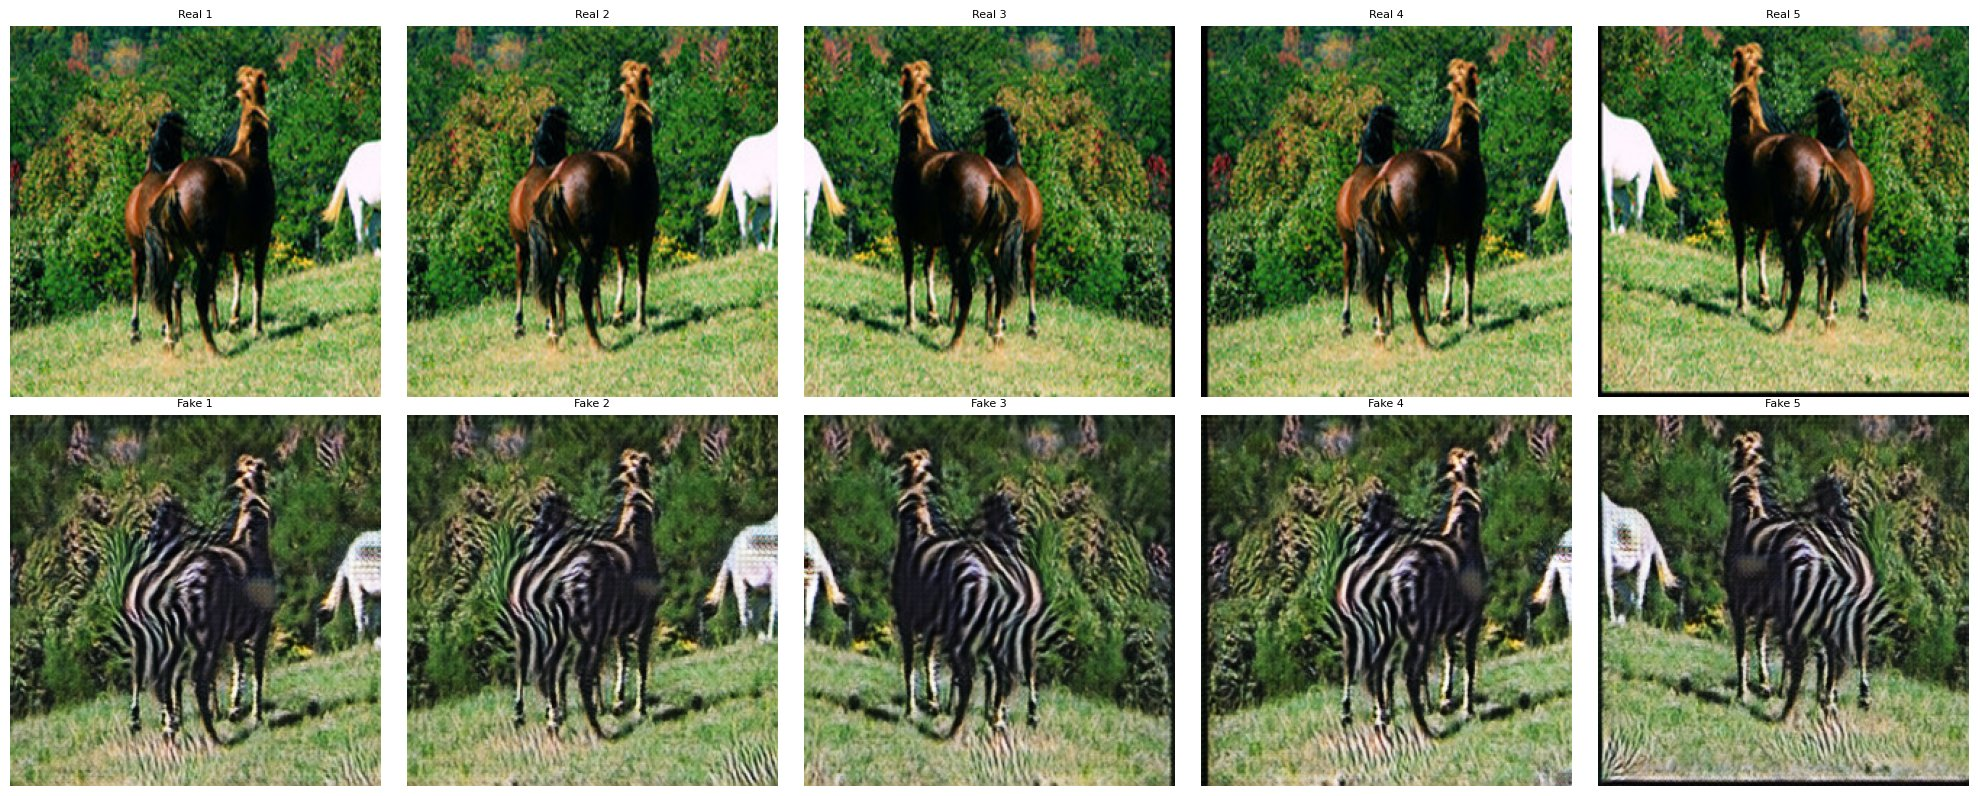

In [55]:
def test_cyclegan_on_dataset(G, loader, n_samples=5):
    """
    Test CycleGAN on a test dataset and display results in grid format.
    
    Args:
        G (nn.Module): Generator model (G_AB or G_BA)
        loader (DataLoader): Test dataloader with batch_size=1
        n_samples (int): Number of samples to display
    """
    real_images = []
    fake_images = []
    
    # Collect n_samples from the loader
    for _ in range(n_samples):
        # Get a new random sample each time (works with shuffle=True)
        real = get_random_batch(loader).to(device)
        with torch.no_grad():
            fake = G(real)
            
        real_images.append(real.cpu())
        fake_images.append(fake.cpu())
    
    # Combine images into grid format
    composite_batch = torch.cat([
        torch.cat(real_images, dim=0),  # First row: real images
        torch.cat(fake_images, dim=0)   # Second row: fake images
    ], dim=0)
    
    # Create titles
    titles = [f"Real {i+1}" for i in range(n_samples)] + \
             [f"Fake {i+1}" for i in range(n_samples)]
    
    # Display with n_samples columns (2 rows)
    show_images(composite_batch, 
                titles=titles,
                ncols=n_samples,  # One column per sample
                figsize=(20, 8))  # Width x Height

# Test visualization
try:
    print("Visualizing Test Data:")
    test_cyclegan_on_dataset(G_AB, test_DataLoader_A, n_samples=5)
except Exception as e:
    print(f"Visualization error: {str(e)}")

In [31]:
def test_cycle_gan(G_AB, folder_path, n_cols=2):
    """
    Args:
        G_AB (nn.Module): Generator from domain A (Horse) to B (Zebra)
        folder_path (str): Path to folder containing horse images
        n_cols (int): Number of columns in display grid
    """

    # Get image paths
    image_paths = list(Path(folder_path).glob('*.jpg')) + list(Path(folder_path).glob('*.png'))
    if not image_paths:
        print(f"No images found in {folder_path}")
        return

    # Process images
    for img_path in image_paths:
        try:
            # Load and preprocess image
            image = Image.open(img_path).convert('RGB')
            image = transform(image).unsqueeze(0).to(device)  # Add batch dimension

            
            with torch.no_grad():
                # Generate zebra version
                fake_zebra = G_AB(image)
                
                # Create comparison grid
                
                comparison = torch.cat([image[:5], fake_zebra[:5]], dim=0)
                
                # Show results
                titles = ["Original Horse", "Generated Zebra"]
                show_images(comparison, 
                           titles=titles, 
                           ncols=n_cols,
                           figsize=(10, 5))
                
        except Exception as e:
            print(f"Error processing {img_path.name}: {str(e)}")

### Out-of-Distribution Generalization (Turkoman Horse Breeds)
Qualitative evaluation of the trained CycleGAN generator on zero-shot / unseen real-world photographs of Iranian Turkoman horses.


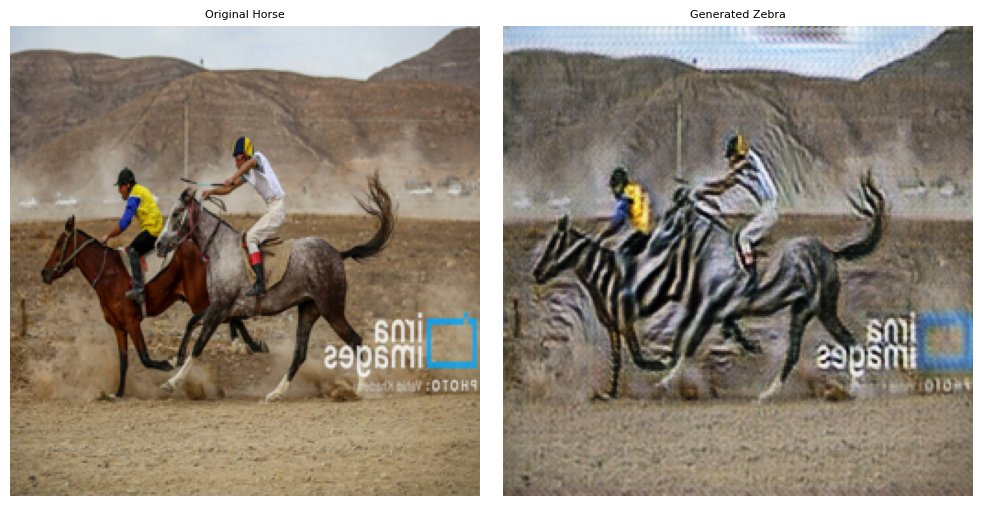

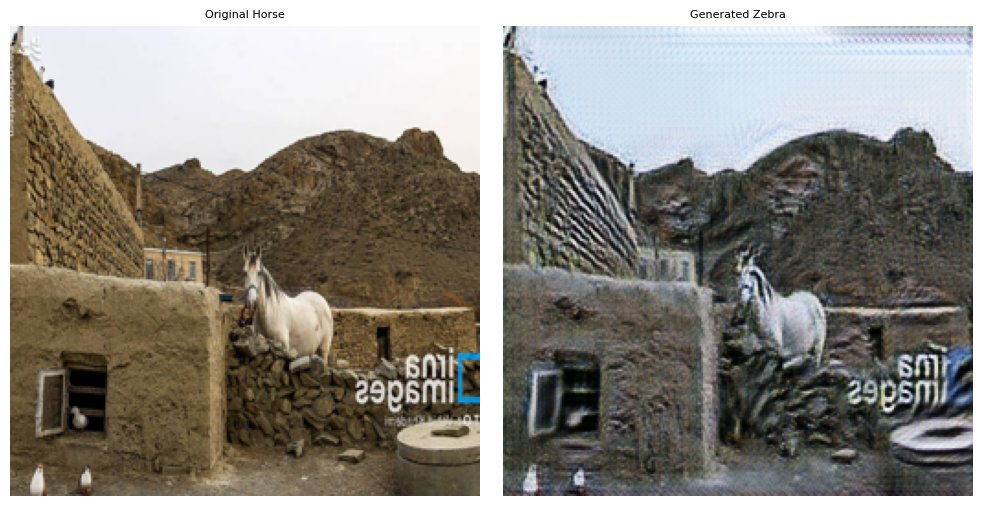

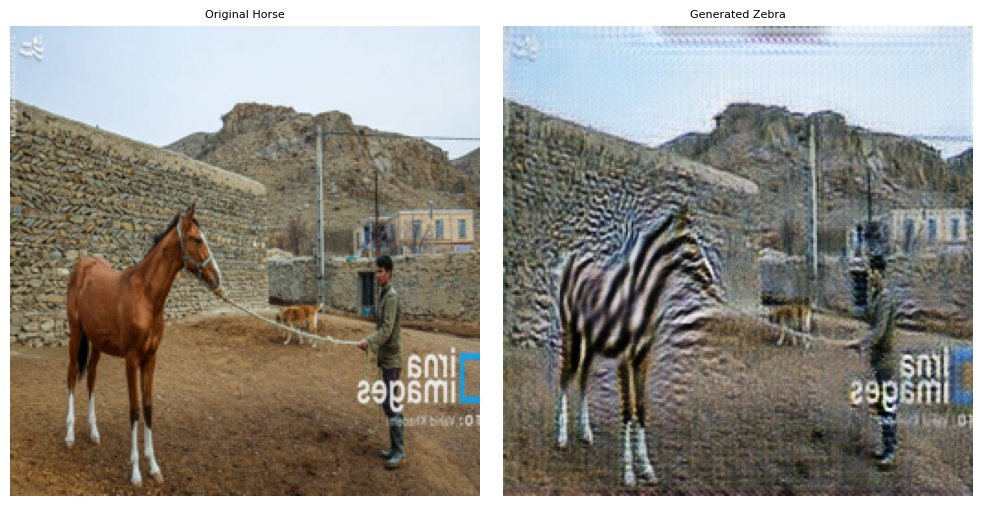

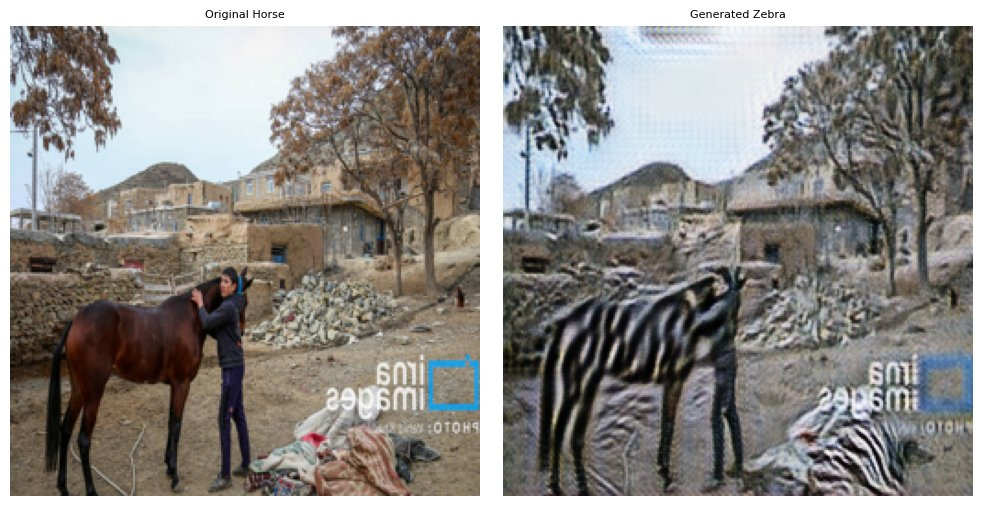

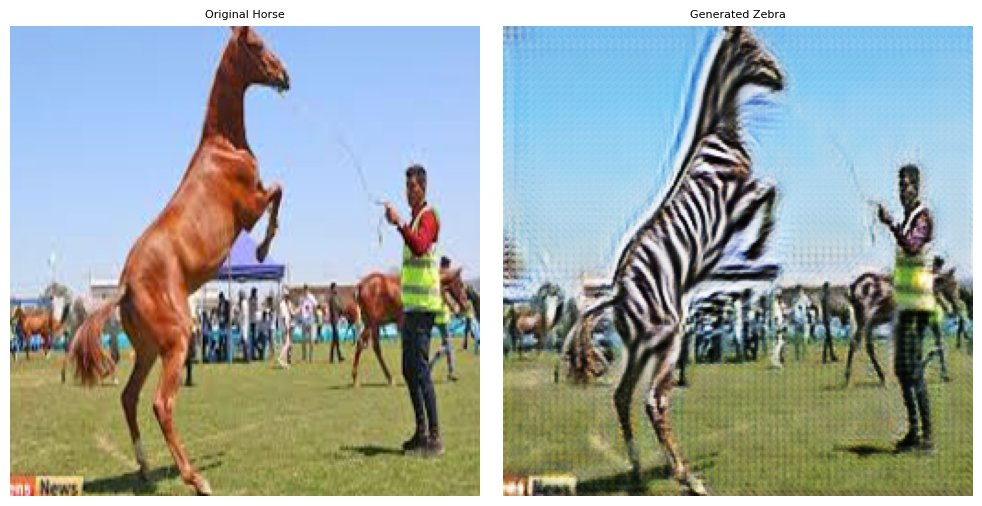

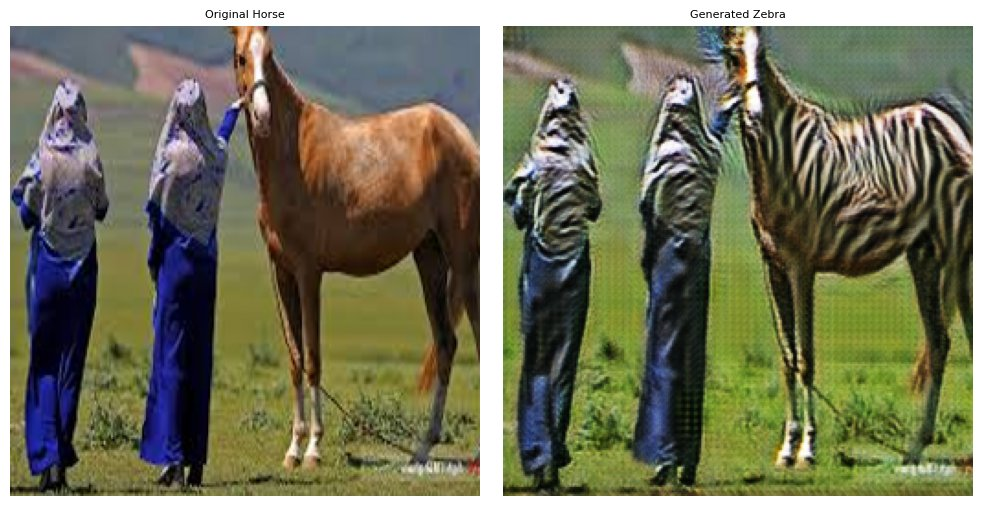

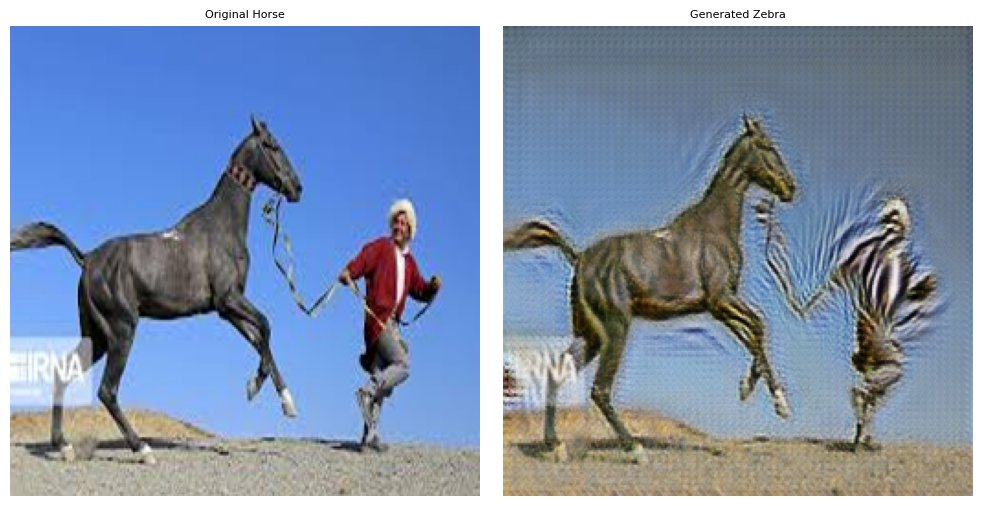

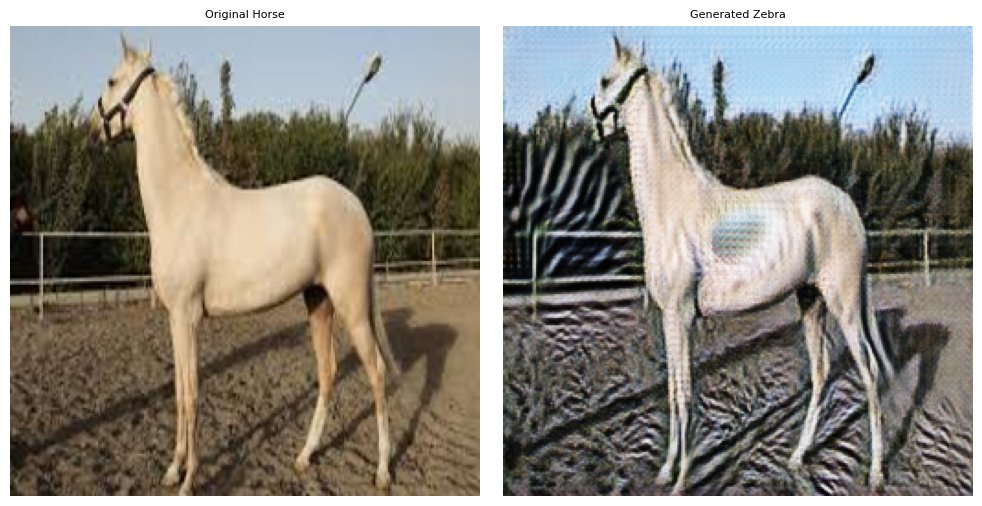

In [37]:
Turkeman_DIR = Path('./src/data/TurkemanHorses')
test_cycle_gan(G_AB, Turkeman_DIR, n_cols=2)